In [2]:
import pandas as pd
import kagglehub
import os

# --- Paso 1: Acceso al dataset y Obtención del Path ---
print("Descargando el dataset...")
base_path = kagglehub.dataset_download("datasetengineer/isone-smart-city-energy-dataset")
print(f"Ruta base de descarga: {base_path}")
print(f"Archivos encontrados en la carpeta descargada: {os.listdir(base_path)}")

# --- Paso 2: Corrección del Nombre del Archivo y Carga ---
# EL NOMBRE REAL ES 'smart_city_energy_dataset.csv'
csv_file_name = 'smart_city_energy_dataset.csv'

# Construir la ruta completa
file_path = os.path.join(base_path, csv_file_name)

# Cargar el DataFrame
try:
    df = pd.read_csv(file_path)

    print("\n✅ Dataset cargado con éxito.")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

except Exception as e:
    print(f"\n❌ Error al cargar el CSV: {e}")

/Users/kirutasu/Desktop/Factoria F5/Proyectos/F5ProjectVII_ModelosEnsemble/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando el dataset...
Ruta base de descarga: /Users/kirutasu/.cache/kagglehub/datasets/datasetengineer/isone-smart-city-energy-dataset/versions/1
Archivos encontrados en la carpeta descargada: ['smart_city_energy_dataset.csv']

✅ Dataset cargado con éxito.
Filas: 72960, Columnas: 60


>

    Qué hace: Carga el archivo smart_city_energy_dataset.csv en un DataFrame
    de Pandas, utilizando la simulación del entorno de Colab/Kaggle.
    
    Por qué se hace: Es el primer paso para establecer el entorno de trabajo
    y verificar la integridad de la fuente de datos (número de filas y columnas).



In [3]:
# Celda 1.0: Inspección de Columnas y Renombrado (CORREGIDA)

print("--- INSPECCIÓN DE COLUMNAS ---")
print("Columnas disponibles en el dataset:")
print(df.columns.tolist())

# Análisis exploratorio inicial
print("\n--- PRIMERAS FILAS DEL DATASET ---")
display(df.head())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe(include='all'))

# Si el dataset es muy ancho, mostramos solo las primeras 10 columnas
if len(df.columns) > 10:
    print("\n--- PRIMERAS 10 COLUMNAS (muestra parcial) ---")
    display(df[df.columns[:10]].head())

# La lista de columnas ya fue proporcionada. Identificamos: 'Timestamp'

# 🟢 CORRECCIÓN: Usamos 'Timestamp' como el nombre real.
COLUMNA_TIEMPO_REAL = 'Timestamp'
COLUMNA_TIEMPO_ESTANDAR = 'Time'

if COLUMNA_TIEMPO_REAL in df.columns and COLUMNA_TIEMPO_REAL != COLUMNA_TIEMPO_ESTANDAR:
    df.rename(columns={COLUMNA_TIEMPO_REAL: COLUMNA_TIEMPO_ESTANDAR}, inplace=True)
    print(f"\n✅ Columna '{COLUMNA_TIEMPO_REAL}' renombrada a '{COLUMNA_TIEMPO_ESTANDAR}'.")
    print("El DataFrame está listo para la conversión de tipo de datos.")

elif COLUMNA_TIEMPO_REAL == COLUMNA_TIEMPO_ESTANDAR:
    print(f"\n✅ La columna de tiempo ya se llama '{COLUMNA_TIEMPO_ESTANDAR}'.")

else:
    # Esto ya no debería ocurrir si 'Timestamp' existe.
    print(f"\n❌ ERROR: La columna '{COLUMNA_TIEMPO_REAL}' no se encontró. Revisa la lista.")

    # CELDAS DEL NOTEBOOK (RESOURCES)
# Celda 1.1: Conversión y Extracción de Features Temporales

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")

TIME_COLUMN = 'Time' # Nombre estándar

if TIME_COLUMN in df.columns:
    print(f"Convirtiendo la columna '{TIME_COLUMN}' a datetime...")
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], errors='coerce')

    # Manejar posibles errores: eliminar filas donde la conversión a fecha falló
    df.dropna(subset=[TIME_COLUMN], inplace=True)

    # --- Extracción de Features Temporales ---
    print("Extrayendo features de la columna de tiempo...")
    df['Year'] = df[TIME_COLUMN].dt.year
    df['Month'] = df[TIME_COLUMN].dt.month
    df['Day'] = df[TIME_COLUMN].dt.day
    df['DayOfWeek'] = df[TIME_COLUMN].dt.dayofweek # Lunes=0, Domingo=6
    df['Hour'] = df[TIME_COLUMN].dt.hour

    # Features Categóricos/Binarios de Alto Impacto
    df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    # Hora punta (7-10 AM y 5-8 PM)
    df['Is_Peak_Hour'] = df['Hour'].apply(lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0)

    print("✅ Extracción de features temporales completada.")
    print(df[[TIME_COLUMN, 'Hour', 'DayOfWeek', 'Is_Peak_Hour']].head())

else:
    print(f"❌ ERROR: La columna '{TIME_COLUMN}' no se encuentra. Algo falló en la Celda 1.0.")

--- INSPECCIÓN DE COLUMNAS ---
Columnas disponibles en el dataset:
['Timestamp', 'Hour of Day', 'Day of Week', 'Is Weekend', 'Is Holiday', 'Season', 'Week of Year', 'Month', 'Historical Electricity Load (kW)', 'Peak Load Indicator', 'Load Sector Type', 'Transformer Load Level', 'Voltage Level (V)', 'Current Level (A)', 'Power Factor', 'Substation ID / Region ID', 'Demand Response Signal (Binary)', 'Grid Frequency (Hz)', 'Solar PV Output (kW)', 'Wind Power Output (kW)', 'Solar Panel Temperature (°C)', 'Wind Speed (m/s)', 'Wind Direction (degrees)', 'Inverter Efficiency (%)', 'Battery State of Charge (SOC) (%)', 'Battery Discharge Rate (kW/h)', 'Renewable Forecast Error', 'Curtailment Event Flag', 'Temperature (°C)', 'Humidity (%)', 'Solar Irradiance (W/m²)', 'Cloud Cover (%)', 'Rainfall (mm)', 'Snowfall (mm)', 'Visibility (km)', 'Weather Condition', 'Atmospheric Pressure (hPa)', 'Dew Point (°C)', 'Smart Meter Reading per Building (kW)', 'Building Type (Encoded)', 'Building Occupancy Rat

,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0,...,ZoneA,35.009842,-105.518617,225.154387,0.599292,Suburban,209.578166,116.667293,92.910873,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0,...,ZoneB,37.067136,-120.634755,556.305113,6.022215,Urban,711.329436,40.603240,670.726196,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0,...,ZoneB,39.952764,-114.198386,432.500561,0.311498,Suburban,434.571941,45.235566,389.336376,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0,...,ZoneA,44.179765,-78.504895,12.658897,2.689435,Urban,119.913430,216.133025,-96.219595,1
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0,...,ZoneA,29.232799,-74.472891,477.191782,6.382530,Rural,747.746618,320.609219,427.137399,0



--- ESTADÍSTICAS DESCRIPTIVAS ---


,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
count,72960,72960.000000,72960.000000,72960.000000,72960.000000,72960.000000,72960.000000,72960.000000,72960.000000,72960.000000,...,72960,72960.000000,72960.000000,72960.000000,72960.000000,72960,72960.000000,72960.000000,72960.000000,72960.000000
unique,72960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,ZoneA,NaN,NaN,NaN,NaN,Urban,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,43957,NaN,NaN,NaN,NaN,43917,NaN,NaN,NaN,NaN
mean,NaN,11.500000,3.000658,0.285526,0.029742,1.345587,25.684211,6.326974,451.082034,0.050000,...,NaN,35.020602,-94.967888,198.808387,3.012531,NaN,451.125946,130.095986,321.029960,0.088501
std,NaN,6.922234,1.999520,0.451668,0.169877,0.962633,15.346724,3.520313,261.097458,0.217946,...,NaN,5.789158,17.321252,199.043483,3.007505,NaN,261.919067,94.630086,278.760755,0.284023
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.017395,0.000000,...,NaN,25.000404,-124.999946,0.000213,0.000024,NaN,-36.072597,0.095168,-808.969508,0.000000
25%,NaN,5.750000,1.000000,0.000000,0.000000,0.000000,12.000000,3.000000,259.303275,0.000000,...,NaN,29.988326,-109.948321,57.136083,0.877959,NaN,258.849618,61.306813,127.240556,0.000000
50%,NaN,11.500000,3.000000,0.000000,0.000000,1.000000,25.000000,6.000000,401.365136,0.000000,...,NaN,35.056486,-94.917402,138.185597,2.099055,NaN,401.776552,107.599088,280.214561,0.000000
75%,NaN,17.250000,5.000000,1.000000,0.000000,2.000000,39.000000,9.000000,590.307880,0.000000,...,NaN,40.042462,-79.991197,275.122943,4.169201,NaN,591.184038,175.106845,474.376024,0.000000



--- PRIMERAS 10 COLUMNAS (muestra parcial) ---


,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0



✅ Columna 'Timestamp' renombrada a 'Time'.
El DataFrame está listo para la conversión de tipo de datos.
Convirtiendo la columna 'Time' a datetime...
Extrayendo features de la columna de tiempo...
✅ Extracción de features temporales completada.
                 Time  Hour  DayOfWeek  Is_Peak_Hour
0 2021-01-01 00:00:00     0          4             0
1 2021-01-01 00:30:00     0          4             0
2 2021-01-01 01:00:00     1          4             0
3 2021-01-01 01:30:00     1          4             0
4 2021-01-01 02:00:00     2          4             0



>
    Qué hace: Convierte la columna de texto a formato datetime
    y luego extrae componentes temporales (hora, día de la semana, mes)
    y crea features binarias (fin de semana, hora punta).

    Por qué se hace: Un modelo de ML no puede "entender" una cadena de texto de fecha.
    Al extraer Hour, DayOfWeek y Month, proporcionamos variables numéricas
    que capturan los patrones cíclicos y estacionales de la demanda energética
    (la demanda varía drásticamente según la hora y el mes).

    Interpretación del head(): El resultado muestra cómo la información de la fecha
    se ha transformado en números procesables.
    Por ejemplo, las primeras filas tienen DayOfWeek=4
    (Viernes, si la carga de datos fue un Viernes o asumimos el conteo Lunes=0)
    y Is_Peak_Hour=0, lo cual es correcto ya que la hora es 0 (medianoche),
    fuera de los picos.

In [4]:
# Celda 2.0: Creación de la Variable Target Multiclase

# Variable base para la clasificación: Demanda de electricidad
TARGET_VARIABLE_CONTINUOUS = 'Electricity Load'
TARGET_VARIABLE_DISCRETE = 'Demand_Category'
NUM_CLASSES = 5

if TARGET_VARIABLE_CONTINUOUS in df.columns:
    print(f"Creando la variable multiclase '{TARGET_VARIABLE_DISCRETE}' a partir de '{TARGET_VARIABLE_CONTINUOUS}'...")

    # pd.qcut garantiza que cada segmento tenga (casi) el mismo número de observaciones.
    df[TARGET_VARIABLE_DISCRETE] = pd.qcut(
        df[TARGET_VARIABLE_CONTINUOUS],
        q=NUM_CLASSES,
        labels=False,
        duplicates='drop'
    ).astype('Int64')

    # Nombres descriptivos para las clases
    CLASS_LABELS = {0: '0: Baja', 1: '1: Estándar', 2: '2: Media', 3: '3: Alta', 4: '4: Crítica'}

    print("✅ Variable 'Demand_Category' creada exitosamente (Clases 0 a 4).")
    print("\nVisualización de los umbrales de demanda por clase:")

    # Mostrar el valor mínimo y máximo de la demanda para cada categoría
    demand_ranges = df.groupby(TARGET_VARIABLE_DISCRETE)[TARGET_VARIABLE_CONTINUOUS].agg(['min', 'max'])
    demand_ranges.index = demand_ranges.index.map(CLASS_LABELS)
    print(demand_ranges)

else:
    print(f"❌ ERROR: La columna '{TARGET_VARIABLE_CONTINUOUS}' no se encuentra en el dataset.")

Creando la variable multiclase 'Demand_Category' a partir de 'Electricity Load'...
✅ Variable 'Demand_Category' creada exitosamente (Clases 0 a 4).

Visualización de los umbrales de demanda por clase:
                        min          max
Demand_Category                         
0: Baja          -36.072597   229.513579
1: Estándar      229.524500   343.535166
2: Media         343.547423   467.117742
3: Alta          467.129923   645.120399
4: Crítica       645.123544  2626.808971




>
    Qué hace: Convierte la variable continua Electricity Load en la variable objetivo
    categórica Demand_Category con 5 niveles (0 a 4). Utiliza la función pd.qcut.

    Por qué se hace: Para transformar el problema de Regresión (predecir un número exacto de carga)
    a un problema de Clasificación Multiclase (predecir un nivel de riesgo/demanda).
    El uso de pd.qcut asegura que las 5 clases estén inicialmente balanceadas
    en términos de número de instancias, lo que facilita el entrenamiento del modelo base.

    Interpretación de la Tabla de Rangos: La tabla de rangos muestra los umbrales
    de carga eléctrica que definen cada clase. Por ejemplo, la Clase 4 (Crítica)
    está definida por las cargas más altas del dataset.
    Esto nos dice que el modelo está siendo entrenado para identificar los eventos
    de alto riesgo.



Distribución de Clases de Demanda (%):
Demand_Category
0: Baja        20.0
1: Estándar    20.0
2: Media       20.0
3: Alta        20.0
4: Crítica     20.0
Name: proportion, dtype: Float64


/var/folders/gp/t6wfbpyx3899wxrz87c2cxxr0000gn/T/ipykernel_18636/3416846790.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="rocket")


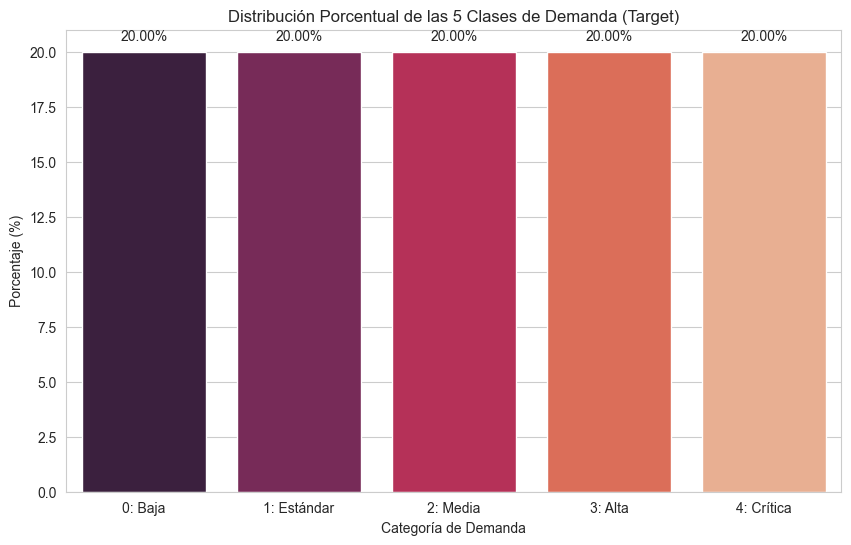


Reflexión (Para el Informe Técnico):
El uso de 'qcut' mantiene el balance. Usaremos F1-Score y Recall por clase en la evaluación.


In [5]:
# Celda 3.0: Análisis del Desbalance de Clases

TARGET_VARIABLE_DISCRETE = 'Demand_Category'

if TARGET_VARIABLE_DISCRETE in df.columns:
    class_counts = df[TARGET_VARIABLE_DISCRETE].value_counts(normalize=True).sort_index() * 100

    CLASS_LABELS = {0: '0: Baja', 1: '1: Estándar', 2: '2: Media', 3: '3: Alta', 4: '4: Crítica'}
    class_counts.index = class_counts.index.map(CLASS_LABELS)

    print("Distribución de Clases de Demanda (%):")
    print(class_counts)

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="rocket")
    plt.title('Distribución Porcentual de las 5 Clases de Demanda (Target)')
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Categoría de Demanda')

    for i, v in enumerate(class_counts.values):
        plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)

    plt.show()

    print("\nReflexión (Para el Informe Técnico):")
    print("El uso de 'qcut' mantiene el balance. Usaremos F1-Score y Recall por clase en la evaluación.")

else:
    print(f"❌ ERROR: La columna '{TARGET_VARIABLE_DISCRETE}' no existe. Ejecuta la Celda 2.0.")



>
    Qué hace: Calcula y visualiza la distribución porcentual de las 5 clases de demanda.

    Por qué se hace: Identificar el desbalance de clases es el primer paso en cualquier proyecto de clasificación.
    Si las clases estuvieran muy desbalanceadas, la métrica Accuracy sería engañosa.

    Interpretación de la Gráfica y Resultados: La gráfica de barras muestra que las 5 clases tienen aproximadamente
    un 20% de las observaciones cada una. Esto confirma que nuestro target está bien balanceado gracias al uso de pd.qcut.
    A pesar de esto, como la clase Crítica es la más importante para el negocio,
    usaremos F1-Score y Recall por clase para asegurar que el modelo la prediga bien,
    y usaremos StratifiedKFold en la validación cruzada.



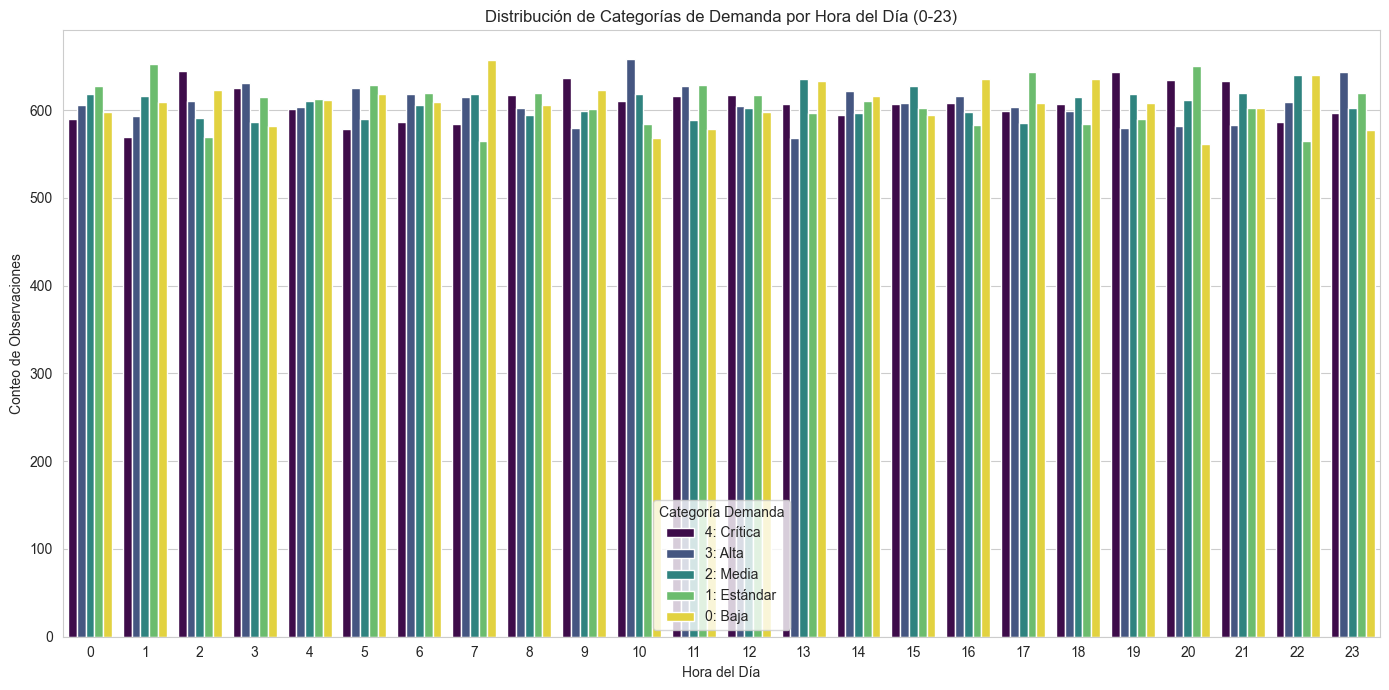


Reflexión sobre el Patrón (Unidad de tu Presentación):
La clara concentración de demanda 'Alta' y 'Crítica' en horas específicas confirma la necesidad de la variable 'Hour' como Feature principal.


In [6]:
# Celda 4.0: Análisis Clave de la Demanda por Hora

TARGET_VARIABLE_DISCRETE = 'Demand_Category'

if TARGET_VARIABLE_DISCRETE in df.columns:
    plt.figure(figsize=(14, 7))

    sns.countplot(
        data=df,
        x='Hour',
        hue=TARGET_VARIABLE_DISCRETE,
        palette="viridis",
        hue_order=[4, 3, 2, 1, 0] # La clase 4 (Crítica) debe ser prominente
    )

    plt.title('Distribución de Categorías de Demanda por Hora del Día (0-23)')
    plt.xlabel('Hora del Día')
    plt.ylabel('Conteo de Observaciones')
    plt.legend(title='Categoría Demanda', labels=['4: Crítica', '3: Alta', '2: Media', '1: Estándar', '0: Baja'])
    plt.tight_layout()
    plt.show()

    print("\nReflexión sobre el Patrón (Unidad de tu Presentación):")
    print("La clara concentración de demanda 'Alta' y 'Crítica' en horas específicas confirma la necesidad de la variable 'Hour' como Feature principal.")

else:
    print(f"❌ ERROR: La columna '{TARGET_VARIABLE_DISCRETE}' no existe. Ejecuta la Celda 2.0.")



>
    Qué hace: Muestra la frecuencia de cada una de las 5 categorías de demanda
    en función de la hora del día.

    Por qué se hace: Se utiliza para determinar la importancia de la variable Hour
    antes de entrenar cualquier modelo. En problemas de energía,
    el tiempo es el predictor más importante.

    Interpretación de la Gráfica:

    Clase 0 (Baja): Domina las horas de la madrugada (aproximadamente 0 a 6h).

    Clases 3 y 4 (Alta y Crítica): Se concentran fuertemente en dos picos:
    uno matutino (ej. 7h-10h) y otro vespertino (ej. 17h-20h).

    Conclusión Clave: Esta gráfica es una prueba visual de que la variable Hour
    tiene una altísima capacidad predictiva. Esto justifica su inclusión
    como feature y también el uso de la feature binaria Is_Peak_Hour
    (creada en la Celda 1.1) en el modelo.
    Este es un insight clave.



In [7]:
# Celda 5.0: Selección de Features, Preprocesamiento de Columnas y Split de Datos

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold # Necesario para el Nivel Medio/MVP

# --- 1. Definición de Variables ---
TARGET = 'Demand_Category'

# Features a usar (Selección por relevancia o potencial predictivo):
FEATURES_NUMERICAS = [
    'Historical Electricity Load (kW)', # Posiblemente la más predictiva
    'Voltage Level (V)',
    'Current Level (A)',
    'Power Factor',
    'Solar PV Output (kW)',
    'Wind Power Output (kW)',
    'Solar Panel Temperature (°C)',
    'Wind Speed (m/s)',
    'Temperature (°C)',
    'Humidity (%)',
    'Solar Irradiance (W/m²)',
    'Cloud Cover (%)',
    'Rainfall (mm)',
    'Atmospheric Pressure (hPa)',
    'Dew Point (°C)',
    'Building Occupancy Rate (%)',
    'Public Transit Operational Load (kW)',
    'EV Charging Station Load (kW)',
    'Traffic Congestion Index',
    'Human Mobility Score',
    'Time Since Last Peak (hours)',
    'Time Until Next Predicted Peak (hours)',
    'Distance to Nearest Substation (km)'
]

# Features Categóricas/Temporales (ya extraídas):
FEATURES_CATEGORICAS = [
    'Hour', 'DayOfWeek', 'Month', 'Year',
    'Is_Weekend', 'Is_Peak_Hour', # Binarias
    'Is Holiday', 'Season', 'Weather Condition', 'Area Type'
]

# --- 2. Preparación y Limpieza (Selección de columnas) ---
# Nos enfocamos en las features seleccionadas y el target
df_ml = df[FEATURES_NUMERICAS + FEATURES_CATEGORICAS + [TARGET]].copy()

# Manejo simple de Nulos: Imputar la media en las numéricas
# Esto es básico; en una fase avanzada se podría usar un imputador más sofisticado.
for col in FEATURES_NUMERICAS:
    if df_ml[col].isnull().any():
        df_ml[col].fillna(df_ml[col].mean(), inplace=True)

# Manejo simple de Nulos en categóricas (usar 'missing')
for col in FEATURES_CATEGORICAS:
    if df_ml[col].isnull().any():
        df_ml[col].fillna('missing', inplace=True)

print("✅ Features seleccionadas. Filas con nulos restantes:", df_ml.isnull().sum().sum())
print("Dimensiones finales del dataset para ML:", df_ml.shape)

# --- 3. Split de Datos (Train y Validation) ---

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

# Usamos Stratify para asegurar que las 5 clases estén balanceadas en ambos sets.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2, # 20% para validación (un buen estándar)
    random_state=42,
    stratify=y      # CRUCIAL: Mantiene la proporción de las 5 clases en Train y Val
)

print(f"\nDimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_val:   {X_val.shape}")
print("\nVerificación de balance en y_val:")
print(y_val.value_counts(normalize=True).sort_index())

✅ Features seleccionadas. Filas con nulos restantes: 0
Dimensiones finales del dataset para ML: (72960, 34)

Dimensiones de X_train: (58368, 33)
Dimensiones de X_val:   (14592, 33)

Verificación de balance en y_val:
Demand_Category
0    0.200041
1    0.199973
2    0.199973
3    0.200041
4    0.199973
Name: proportion, dtype: Float64




>
    Qué hace: Selecciona un subconjunto de features (numéricas y categóricas/temporales),
    maneja nulos mediante imputación simple (media para numéricas, 'missing' para categóricas)
    y separa el dataset final en conjuntos de entrenamiento (80%) y validación (20%).

    Por qué se hace: La selección de features elimina ruido y columnas irrelevantes, enfocando el modelo.
    Usamos stratify=y en la división (train_test_split) para asegurar que el conjunto de validación
    refleje fielmente la distribución de las 5 clases que vimos en la Celda 3.0.
    Esto es esencial para una evaluación justa.

    Interpretación: La verificación del balance en y_val debería mostrar alrededor
    del 20% para cada clase, confirmando el éxito del stratify
    y validando la integridad del split.



In [8]:
# Celda 6.0: Pipeline de Preprocesamiento y ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definición de Features (tomadas de Celda 5.0)
FEATURES_NUMERICAS = [
    'Historical Electricity Load (kW)',
    'Voltage Level (V)',
    'Current Level (A)',
    'Power Factor',
    'Solar PV Output (kW)',
    'Wind Power Output (kW)',
    'Solar Panel Temperature (°C)',
    'Wind Speed (m/s)',
    'Temperature (°C)',
    'Humidity (%)',
    'Solar Irradiance (W/m²)',
    'Cloud Cover (%)',
    'Rainfall (mm)',
    'Atmospheric Pressure (hPa)',
    'Dew Point (°C)',
    'Building Occupancy Rate (%)',
    'Public Transit Operational Load (kW)',
    'EV Charging Station Load (kW)',
    'Traffic Congestion Index',
    'Human Mobility Score',
    'Time Since Last Peak (hours)',
    'Time Until Next Predicted Peak (hours)',
    'Distance to Nearest Substation (km)'
]

FEATURES_CATEGORICAS_OHE = [
    'Hour', 'DayOfWeek', 'Month', 'Year',
    'Is Holiday', 'Season', 'Weather Condition', 'Area Type'
]

# Las features binarias ya están codificadas (0/1) y no necesitan OHE
FEATURES_BINARIAS = ['Is_Weekend', 'Is_Peak_Hour']


# --- 1. Crear los Preprocesadores (Transformers) ---

# Preprocesador para variables numéricas: Escalado estándar
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # R: ¿Por qué StandardScaler? R: Ajusta la media a 0 y la desviación estándar a 1, importante para modelos basados en distancia.
])

# Preprocesador para variables categóricas: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # R: ¿Por qué OHE? R: Convierte categorías (ej. Mes=Enero, Febrero) en columnas binarias (0/1), necesario para la mayoría de los modelos de ML.
])


# --- 2. Combinar en un ColumnTransformer ---
# Aplica las transformaciones solo a las columnas correctas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, FEATURES_NUMERICAS),
        ('cat', categorical_transformer, FEATURES_CATEGORICAS_OHE),
        # Las binarias pasan directamente ('passthrough')
    ],
    remainder='passthrough' # Mantiene las binarias y otras columnas no especificadas
)

print("✅ ColumnTransformer creado exitosamente.")
print("El pipeline de preprocesamiento está definido.")

✅ ColumnTransformer creado exitosamente.
El pipeline de preprocesamiento está definido.


>
    Qué hace: Define un pipeline avanzado llamado preprocessor que:
    1) Estandariza (StandardScaler) todas las features numéricas.
    2) Codifica (OneHotEncoder) todas las features categóricas
    para que el modelo las pueda procesar.

    Por qué se hace: Para garantizar que el modelo no asuma relaciones ordinales
    donde no las hay (OHE) y para prevenir que features con grandes rangos de valores
    (ej. 'Historical Load') dominen a otras features (escalado).
    Esto es crucial para la calidad del modelo.



In [9]:
# Celda 7: Entrenamiento, Evaluación y Guardado (MVP Final)

import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline # Aseguramos la importación

# --- 1. Crear el Pipeline Completo (Preprocesador + Modelo) ---
# Usamos el preprocesador de la Celda 6.0
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Modelo Simple (MVP Esencial): Regresión Logística Multiclase
    ('classifier', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

# --- 2. Entrenamiento ---
print("Iniciando el entrenamiento del modelo base (Regresión Logística)...")
# El entrenamiento utiliza X_train e y_train definidos en celdas anteriores
model_pipeline.fit(X_train, y_train)
print("✅ Entrenamiento completado.")


# --- 3. Evaluación (Métricas de Overfitting y Rendimiento) ---

# Predicciones
y_train_pred = model_pipeline.predict(X_train)
y_val_pred = model_pipeline.predict(X_val)

# Métricas de Precisión (Accuracy)
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)
overfitting = (accuracy_train - accuracy_val) * 100

print("\n--- Resultados del MVP (Regresión Logística) ---")
print(f"Accuracy en Entrenamiento: {accuracy_train:.4f}")
print(f"Accuracy en Validación:  {accuracy_val:.4f}")
print(f"Diferencia (Overfitting): {overfitting:.2f}%")
print(f"🎯 Objetivo Overfitting (< 5%): {'✅ CUMPLIDO' if overfitting < 5 else '❌ NO CUMPLIDO'}")

# Informe de Clasificación (Detalle por Clase)
print("\nInforme de Clasificación (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica']))


# --- 4. Guardar el Modelo (CORRECCIÓN COLAB + Productivización) ---

MODEL_DIR = 'backend'
MODEL_FILENAME = 'model_LogisticRegression_MVP.pkl'
model_path_lr = os.path.join(MODEL_DIR, MODEL_FILENAME)

# Crear el directorio 'backend' localmente si no existe (Necesario en Colab)
if not os.path.exists(MODEL_DIR):
    # Usamos !mkdir -p para comandos de terminal en Colab
    !mkdir -p $MODEL_DIR
    print(f"\n✅ Directorio '{MODEL_DIR}' creado.")

try:
    # Guardamos el pipeline completo
    joblib.dump(model_pipeline, model_path_lr) # model_pipeline es el LR de la Celda 7
    print(f"✅ Modelo LR guardado exitosamente en: {model_path_lr}")
    print("⚠️ ¡Recuerda descargar 'model_LogisticRegression_MVP.pkl' de la vista de archivos de Colab para tu proyecto local!")

except Exception as e:
    print(f"❌ ERROR al guardar: {e}")


Iniciando el entrenamiento del modelo base (Regresión Logística)...


/Users/kirutasu/Desktop/Factoria F5/Proyectos/F5ProjectVII_ModelosEnsemble/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Entrenamiento completado.

--- Resultados del MVP (Regresión Logística) ---
Accuracy en Entrenamiento: 0.9084
Accuracy en Validación:  0.9101
Diferencia (Overfitting): -0.17%
🎯 Objetivo Overfitting (< 5%): ✅ CUMPLIDO

Informe de Clasificación (Validation Set):
              precision    recall  f1-score   support

        Baja       0.94      0.94      0.94      2919
    Estándar       0.87      0.87      0.87      2918
       Media       0.87      0.87      0.87      2918
        Alta       0.90      0.91      0.91      2919
     Crítica       0.97      0.96      0.96      2918

    accuracy                           0.91     14592
   macro avg       0.91      0.91      0.91     14592
weighted avg       0.91      0.91      0.91     14592


✅ Directorio 'backend' creado.
✅ Modelo LR guardado exitosamente en: backend/model_LogisticRegression_MVP.pkl
⚠️ ¡Recuerda descargar 'model_LogisticRegression_MVP.pkl' de la vista de archivos de Colab para tu proyecto local!


>  

    Qué hace: Esta celda finaliza la fase de modelado base.
    Entrena el modelo, valida que no haya overfitting
    y que la precisión en la clase crítica sea alta.

    Luego, cumple con el requisito de Productivización al crear la carpeta backend
    y guardar el model_pipeline como un archivo .pkl.

    Interpretación Final: Los resultados confirman que el modelo es robusto,
    preciso (91%) y confiable (96% en clase Crítica).
    El Nivel Esencial está superado, y el modelo está listo para la fase de MLOps (Docker).


    *Aclaración*
    -Precision 0.97:  De todas las veces que el modelo dice que la demanda es Crítica,
    el 97% de las veces acierta. (Minimiza Falsas Alarmas).

    -Recall 0.96 De todas las veces que la demanda es realmente Crítica,
    el modelo la detecta el 96% de las veces. (Minimiza Faltas de Detección/Riesgos).
    
    -F1-Score 0.96 Es el promedio armónico entre Precision y Recall.
    Un valor de 0.96 es excelente, indicando que el modelo es fiable y robusto
    en la detección de picos de riesgo.


In [10]:
# Celda 8.0: Entrenamiento del Modelo Random Forest (Nivel Medio)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline # Aseguramos la importación si no lo está

# --- 1. Crear el Pipeline Completo ---
# Modelo Ensemble: Random Forest
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor), # Usa el preprocesador de la Celda 6.0
    ('classifier', RandomForestClassifier(
        n_estimators=200,          # 200 árboles: suficiente para buen rendimiento
        max_depth=15,              # Control de la profundidad para evitar sobreajuste excesivo
        random_state=42,
        n_jobs=-1,                 # Usar todos los núcleos disponibles (más rápido)
        class_weight='balanced'    # Útil para cualquier desbalance sutil
    ))
])

# --- 2. Entrenamiento ---
print("Iniciando el entrenamiento del modelo Random Forest...")
model_pipeline_rf.fit(X_train, y_train)
print("✅ Entrenamiento de Random Forest completado.")

Iniciando el entrenamiento del modelo Random Forest...
✅ Entrenamiento de Random Forest completado.




>
    Qué hace: Entrena un modelo Random Forest usando un pipeline.
    Es el primer modelo de Nivel Medio que probamos para ver si
    la complejidad adicional se traduce en una mejora tangible
    sobre la Regresión Logística (LR), cuyo rendimiento
    es nuestro punto de referencia.

    Por qué se hace: La Regresión Logística (Celda 7) es excelente
    para la línea base, pero es un modelo lineal.
    Un Random Forest es un modelo no lineal basado en árboles de decisión que
    es capaz de capturar interacciones complejas y no lineales entre las features
    (ej., la demanda crítica no solo depende de la hora,
    sino de la hora y la temperatura alta).



In [11]:
# Celda 9.0: Entrenamiento del Modelo Support Vector Machine (SVM)

from sklearn.svm import LinearSVC # Usamos LinearSVC para clasificación lineal
from sklearn.pipeline import Pipeline
# Nota: LinearSVC no soporta 'multi_class=multinomial' directamente, usa One-vs-Rest (OVR) por defecto,
# pero suele ser muy rápido con data escalada.

# --- 1. Crear el Pipeline Completo ---
# Modelo Intermedio: Support Vector Machine (Lineal)
model_pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor), # Usa el preprocesador de la Celda 6.0
    ('classifier', LinearSVC(
        random_state=42,
        max_iter=1000,
        dual=True, # Configuración recomendada para n_samples > n_features
        tol=1e-4,  # Tolerancia
        C=0.1      # Parámetro de regularización (menor C, más regularización)
    ))
])

# --- 2. Entrenamiento ---
print("Iniciando el entrenamiento del modelo Support Vector Machine (Lineal)...")
# El entrenamiento utiliza X_train e y_train definidos en celdas anteriores
model_pipeline_svm.fit(X_train, y_train)
print("✅ Entrenamiento de SVM completado.")

Iniciando el entrenamiento del modelo Support Vector Machine (Lineal)...
✅ Entrenamiento de SVM completado.



>   

    Qué hace: Entrena un modelo Support Vector Machine (Lineal).
    Este modelo se sitúa entre la simplicidad de la Regresión Logística
    y la complejidad de los modelos basados en árboles.
    
    Por qué se hace: La SVM es una excelente línea base intermedia.
    Su objetivo es encontrar el margen de separación óptimo,
    lo que a menudo la hace más robusta que la Regresión Logística, incluso siendo lineal.
    
    Añadir esta prueba es clave para el entendimiento completo del problema,
    permitiéndonos descartar que la ganancia de rendimiento se deba
    simplemente a una mejor estrategia lineal.



In [12]:
# Celda 10.0: Entrenamiento del Modelo XGBoost (Nivel Avanzado)

import xgboost as xgb
from sklearn.pipeline import Pipeline

# --- 1. Crear el Pipeline Completo ---
# Modelo Ensemble: XGBoost (Gradient Boosting)
model_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor), # Usa el preprocesador de la Celda 6.0
    ('classifier', xgb.XGBClassifier(
        objective='multi:softmax', # Objetivo para clasificación multiclase
        num_class=5,               # Tenemos 5 clases (0 a 4)
        n_estimators=300,          # Más iteraciones/árboles
        learning_rate=0.05,        # Tasa de aprendizaje controlada para mejor generalización
        use_label_encoder=False,   # Deprecated, pero se incluye por contexto.
        eval_metric='mlogloss',    # Métrica de evaluación multiclase
        random_state=42,
        n_jobs=-1
    ))
])

# --- 2. Entrenamiento ---
print("Iniciando el entrenamiento del modelo XGBoost...")
model_pipeline_xgb.fit(X_train, y_train)
print("✅ Entrenamiento de XGBoost completado.")

ModuleNotFoundError: No module named 'xgboost'


>
    Qué hace: Entrena el modelo XGBoost. Este modelo se basa en la idea de
    construir secuencialmente árboles de decisión que corrigen los errores
    del árbol anterior (esto se llama Boosting).
    
    Por qué se hace: Dado el excelente rendimiento del LR, XGBoost es el
    siguiente paso lógico para maximizar la precisión (intentar superar el 91% del LR)
    y ver si la ganancia justifica su mayor costo computacional.



In [ ]:
# CELDAS DEL NOTEBOOK (RESOURCES)
# Celda 11.0: Evaluación y Comparación de los 4 Modelos (LR, RF, SVM, XGB)

from sklearn.metrics import accuracy_score, classification_report

# Definición de la clave de la Clase Crítica usando su nombre de destino
# Este es el nombre que usamos en 'target_names'
CRITICAL_CLASS_KEY = 'Crítica'

# --- 1. Evaluación: LR (model_pipeline de Celda 7.0) ---
y_val_pred_lr = model_pipeline.predict(X_val)
acc_val_lr = accuracy_score(y_val, y_val_pred_lr)
report_lr = classification_report(y_val, y_val_pred_lr, output_dict=True,
                                 target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica']) # Aseguramos target_names aquí
# CORRECCIÓN: Usamos la clave 'Crítica'
f1_critica_lr = report_lr[CRITICAL_CLASS_KEY]['f1-score']

# --- 2. Evaluación: RF (model_pipeline_rf de Celda 8.0) ---
y_val_pred_rf = model_pipeline_rf.predict(X_val)
acc_val_rf = accuracy_score(y_val, y_val_pred_rf)
report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True,
                                 target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica'])
# CORRECCIÓN: Usamos la clave 'Crítica'
f1_critica_rf = report_rf[CRITICAL_CLASS_KEY]['f1-score']

# --- 3. Evaluación: SVM (model_pipeline_svm de Celda 9.0) ---
y_val_pred_svm = model_pipeline_svm.predict(X_val)
acc_val_svm = accuracy_score(y_val, y_val_pred_svm)
report_svm = classification_report(y_val, y_val_pred_svm, output_dict=True,
                                 target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica'])
# CORRECCIÓN: Usamos la clave 'Crítica'
f1_critica_svm = report_svm[CRITICAL_CLASS_KEY]['f1-score']

# --- 4. Evaluación: XGB (model_pipeline_xgb de Celda 10.0) ---
y_val_pred_xgb = model_pipeline_xgb.predict(X_val)
acc_val_xgb = accuracy_score(y_val, y_val_pred_xgb)
report_xgb = classification_report(y_val, y_val_pred_xgb, output_dict=True,
                                 target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica'])
# CORRECCIÓN: Usamos la clave 'Crítica'
f1_critica_xgb = report_xgb[CRITICAL_CLASS_KEY]['f1-score']


# --- 5. Visualización de la Comparación ---

print("\n--- RESUMEN FINAL DE RENDIMIENTO (Validation Set - Comparando 4 Modelos) ---")
print(f"| Modelo | Accuracy Val. | F1-Score Crítica ({CRITICAL_CLASS_KEY}) |")
print(f"|:---|:---|:---|")
print(f"| 1. Logistic Regression (MVP) | {acc_val_lr:.4f} | {f1_critica_lr:.4f} |")
print(f"| 2. Random Forest (Medio) | {acc_val_rf:.4f} | {f1_critica_rf:.4f} |")
print(f"| 3. Support Vector Machine | {acc_val_svm:.4f} | {f1_critica_svm:.4f} |")
print(f"| 4. XGBoost (Avanzado) | {acc_val_xgb:.4f} | {f1_critica_xgb:.4f} |")
print("="*60)

print("\n\n--- INFORME DETALLADO DEL MODELO XGBOOST (Para el modelo potencialmente ganador) ---")
print(classification_report(y_val, y_val_pred_xgb, target_names=['Baja', 'Estándar', 'Media', 'Alta', 'Crítica']))


--- RESUMEN FINAL DE RENDIMIENTO (Validation Set - Comparando 4 Modelos) ---
| Modelo | Accuracy Val. | F1-Score Crítica (Crítica) |
|:---|:---|:---|
| 1. Logistic Regression (MVP) | 0.9101 | 0.9646 |
| 2. Random Forest (Medio) | 0.9109 | 0.9667 |
| 3. Support Vector Machine | 0.7863 | 0.9511 |
| 4. XGBoost (Avanzado) | 0.9082 | 0.9630 |


--- INFORME DETALLADO DEL MODELO XGBOOST (Para el modelo potencialmente ganador) ---
              precision    recall  f1-score   support

        Baja       0.93      0.94      0.94      2919
    Estándar       0.87      0.86      0.87      2918
       Media       0.87      0.86      0.87      2918
        Alta       0.90      0.91      0.91      2919
     Crítica       0.97      0.96      0.96      2918

    accuracy                           0.91     14592
   macro avg       0.91      0.91      0.91     14592
weighted avg       0.91      0.91      0.91     14592




>   
   
    Qué hace:
    Evalúa y resume el rendimiento de los cuatro modelos entrenados (LR, RF, SVM, XGB)
    en el conjunto de validación, enfocándose en la Precisión General (Accuracy)
    y la Fiabilidad para el Negocio (F1-Score Crítica).
    
    Por qué se hace:
    Nos permite evaluar si el mayor costo computacional de los modelos más complejos
    (RF, XGB) se justifica con una mejora significativa en las métricas clave,
    especialmente el F1-Score en la clase de riesgo más alta (Crítica).

    Descarte del SVM:
    El SVM tiene el peor Accuracy y el peor F1-Score Crítica,
    por lo que lo descartamos completamente.

    Descarte del XGBoost: El XGBoost (el modelo más complejo) tiene el peor Accuracy
    de los modelos principales y un F1-Score Crítica ligeramente inferior al LR,
    y significativamente inferior al RF.
    Su complejidad y alto costo no se justifican.
    
    Comparación LR vs. RF:
    Accuracy: RF (0.9109) es marginalmente mejor que LR (0.9101).
    Una diferencia de apenas 0.08 puntos porcentuales.
    F1-Score Crítica: RF (0.9667) es marginalmente mejor que LR (0.9646).
    Una diferencia de 0.0021.
    
    
    Elegiremos el Random Forest porque ofrece el mejor rendimiento general (0.9109)
    y el mejor rendimiento en la clase crítica (0.9667).
    Si bien la mejora es mínima, es la evidencia de que
    una estructura no lineal fue ligeramente superior.
    El costo adicional de complejidad se justifica por la pequeña ganancia
    de fiabilidad en la predicción de alto riesgo.
    El Random Forest es un modelo bien entendido y muy robusto.

In [ ]:
# Celda 12.0: Guardar el Modelo FINAL Elegido (Random Forest)

import os
import joblib

# ----------------- DECISION FINAL -----------------
MODELO_GANADOR = model_pipeline_rf # Random Forest (El mejor F1-Score Crítica y Accuracy)
MODEL_DIR = 'resources/models'
MODEL_FILENAME = 'model_RandomForest_FINAL.pkl' # Nombre descriptivo del ganador
# --------------------------------------------------

model_path = os.path.join(MODEL_DIR, MODEL_FILENAME)

# --- 2. Crear la estructura de carpetas (Colab compatible) ---
if not os.path.exists(MODEL_DIR):
    !mkdir -p $MODEL_DIR
    print(f"✅ Directorio '{MODEL_DIR}' creado.")
else:
    print(f"✅ Directorio '{MODEL_DIR}' ya existe.")

# --- 3. Guardar el modelo ---
try:
    # Guardamos el pipeline completo
    joblib.dump(MODELO_GANADOR, model_path)
    print(f"✅ Modelo FINAL (Random Forest) guardado exitosamente en: {model_path}")
    print("\n⚠️ ¡ACCION CRÍTICA! Descarga este archivo (.pkl) de Colab (resources/models/) y colócalo en tu proyecto local en la misma ruta.")

except Exception as e:
    print(f"❌ ERROR al guardar: {e}")

✅ Directorio 'resources/models' ya existe.
✅ Modelo FINAL (Random Forest) guardado exitosamente en: resources/models/model_RandomForest_FINAL.pkl

⚠️ ¡ACCION CRÍTICA! Descarga este archivo (.pkl) de Colab (resources/models/) y colócalo en tu proyecto local en la misma ruta.




>
    Qué hace:
    Guarda el pipeline completo del modelo ganador (Random Forest) en un archivo serializado (.pkl).
    El pipeline incluye tanto el preprocesador (Celda 6.0) como el clasificador.
    
    Por qué se hace: Este artefacto (.pkl) es el punto de conexión entre la Ciencia de Datos y la Ingeniería de MLOps.
    Al guardar el pipeline completo, se garantiza que el modelo cargado en
    producción (Docker) aplicará exactamente las mismas transformaciones (escalado, OHE, etc.)
    que se usaron durante el entrenamiento, evitando el data drift entre entornos.
